num_leaves	min_data_in_leaf	trees	log_loss	auc
3	15	20	630	0.2497	0.9626
7	31	50	333	0.2540	0.9606
6	31	20	292	0.2569	0.9602
4	15	50	658	0.2578	0.9598
1	7	50	1058	0.2601	0.9590
8	31	150	369	0.2601	0.9584
0	7	20	1117	0.2613	0.9584
5	15	150	426	0.2664	0.9563
2	7	150	847	0.2721	0.9544


	farm_weight	trees	log_loss	auc
0	0.0	269	0.2925	0.9477
1	0.5	527	0.2546	0.9606
2	1.0	658	0.2578	0.9598
3	2.0	527	0.2538	0.9619
4	4.0	750	0.2563	0.9603


PARAMS = {
    "objective": "cross_entropy",   # accepts soft labels like 0.75 (plain "binary" does not)
    "learning_rate": 0.05,
    "num_leaves": 15,
    "min_data_in_leaf": 50,
    "feature_fraction": 0.8,
    "feature_pre_filter": False,    # lets you change min_data_in_leaf between runs
    "verbose": -1,
    "seed": 0,
}

model.best_iteration = 658

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss
from helpers import load, feature_names, swap_sides, organic_splits

In [2]:
organic, farm = load()
names = feature_names()
train, val, test = organic_splits(organic)   # exactly the split you built in Notebook 1
print(len(train), len(val), len(test))

1287 477 445


In [3]:
def score(name, y, p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return {"model": name,
            "log_loss": log_loss(y, p, labels=[0, 1]),
            "auc": roc_auc_score(y, p),
            "brier": brier_score_loss(y, p)}

def predict(model, df):
    """P(A wins), asked from both sides and averaged, exactly as the bot will ask it."""
    p_ab = model.predict(df[names], num_iteration=model.best_iteration or None)
    p_ba = model.predict(swap_sides(df, names)[names], num_iteration=model.best_iteration or None)
    return (p_ab + (1 - p_ba)) / 2

In [4]:
held_out = set(val.aOriginalPlayerId) | set(test.aOriginalPlayerId)

def without_characters(farm_rows, ids):
    return farm_rows[~(farm_rows.aOriginalPlayerId.isin(ids) | farm_rows.bOriginalPlayerId.isin(ids))]

farm_train = without_characters(farm, held_out)
print(len(farm_train), "of", len(farm), "farm matchups are safe to train on")

1907 of 6000 farm matchups are safe to train on


In [5]:
def build(organic_rows, farm_rows, farm_weight=1.0):
    both = pd.concat([
        organic_rows.assign(weight=1.0),
        farm_rows.assign(weight=farm_rows.repeats / 4 * farm_weight),
    ], ignore_index=True)
    # Every matchup from both sides: teaches P(A beats B) = 1 - P(B beats A).
    return pd.concat([both, swap_sides(both, names)], ignore_index=True)

table = build(train, farm_train)
print(table.shape, "mean label:", table.label.mean().round(3))

(6388, 267) mean label: 0.5


In [6]:
PARAMS = {
    "objective": "cross_entropy",   # accepts soft labels like 0.75 (plain "binary" does not)
    "learning_rate": 0.05,
    "num_leaves": 15,
    "min_data_in_leaf": 50,
    "feature_fraction": 0.8,
    "feature_pre_filter": False,    # lets you change min_data_in_leaf between runs
    "verbose": -1,
    "seed": 0,
}

def fit(params, table, valid_df, rounds=2000):
    dtrain = lgb.Dataset(table[names], label=table.label, weight=table.weight,
                         feature_name=names, free_raw_data=False)
    dval = lgb.Dataset(valid_df[names], label=valid_df.label, reference=dtrain)
    history = {}
    model = lgb.train(params, dtrain, rounds,
                      valid_sets=[dtrain, dval], valid_names=["train", "val"],
                      callbacks=[lgb.early_stopping(100, verbose=False),
                                 lgb.record_evaluation(history)])
    return model, history

model, history = fit(PARAMS, table, val)
print("trees used:", model.best_iteration)

trees used: 622


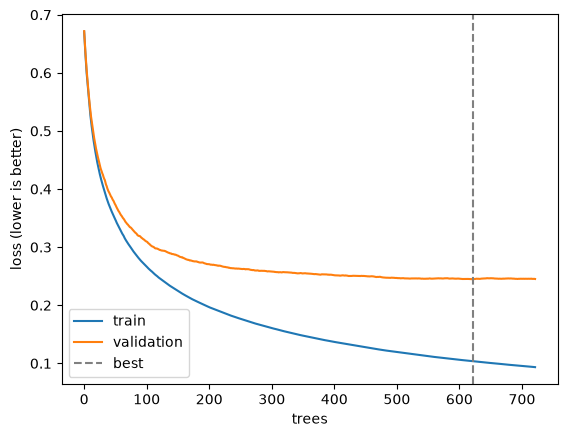

In [7]:
plt.plot(history["train"]["cross_entropy"], label="train")
plt.plot(history["val"]["cross_entropy"], label="validation")
plt.axvline(model.best_iteration, color="grey", linestyle="--", label="best")
plt.xlabel("trees"); plt.ylabel("loss (lower is better)"); plt.legend(); plt.show()

In [8]:
baseline = LogisticRegression().fit(train[["log_heur_power_ratio"]], train.label)
pd.DataFrame([
    score("baseline: LR on heuristic", val.label, baseline.predict_proba(val[["log_heur_power_ratio"]])[:, 1]),
    score("LightGBM", val.label, predict(model, val)),
]).round(4)

,model,log_loss,auc,brier
0,baseline: LR on heuristic,0.5973,0.7686,0.2022
1,LightGBM,0.2433,0.9629,0.0771


In [9]:
rows = []
for num_leaves in [7, 15, 31]:
    for min_data in [20, 50, 150]:
        m, _ = fit(dict(PARAMS, num_leaves=num_leaves, min_data_in_leaf=min_data), table, val)
        s = score("", val.label, predict(m, val))
        rows.append({"num_leaves": num_leaves, "min_data_in_leaf": min_data,
                     "trees": m.best_iteration, "log_loss": s["log_loss"], "auc": s["auc"]})
pd.DataFrame(rows).sort_values("log_loss").round(4)

,num_leaves,min_data_in_leaf,trees,log_loss,auc
1,7,50,1470,0.2432,0.9633
4,15,50,622,0.2433,0.9629
3,15,20,604,0.2454,0.9618
2,7,150,1211,0.2491,0.9622
0,7,20,710,0.2504,0.9627
5,15,150,649,0.2515,0.9612
7,31,50,361,0.2515,0.9610
8,31,150,301,0.2524,0.9606
6,31,20,299,0.2535,0.9602


In [10]:
rows = []
for farm_weight in [0, 0.5, 1, 2, 4]:
    rows_used = farm_train if farm_weight else farm_train.iloc[:0]
    m, _ = fit(PARAMS, build(train, rows_used, farm_weight or 1), val)
    s = score("", val.label, predict(m, val))
    rows.append({"farm_weight": farm_weight, "trees": m.best_iteration,
                 "log_loss": s["log_loss"], "auc": s["auc"]})
pd.DataFrame(rows).round(4)

,farm_weight,trees,log_loss,auc
0,0.0,320,0.2828,0.9521
1,0.5,534,0.2473,0.9619
2,1.0,622,0.2433,0.9629
3,2.0,581,0.2448,0.9625
4,4.0,658,0.2442,0.9625


In [11]:
table = build(train, farm_train)          # rebuild with your chosen settings
model, history = fit(PARAMS, table, val)
pd.DataFrame([
    score("baseline", test.label, baseline.predict_proba(test[["log_heur_power_ratio"]])[:, 1]),
    score("LightGBM", test.label, predict(model, test)),
]).round(4)

,model,log_loss,auc,brier
0,baseline,0.5656,0.7901,0.1883
1,LightGBM,0.2181,0.9712,0.0672


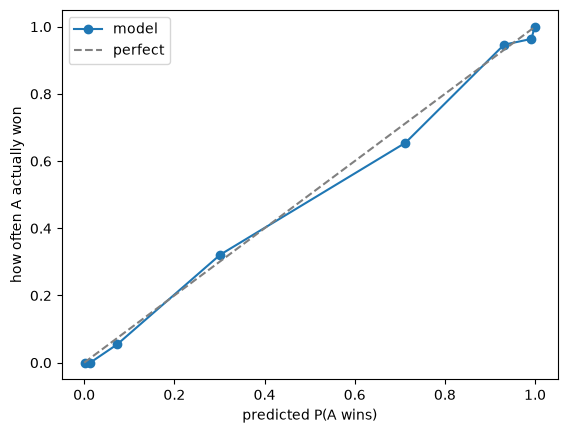

In [12]:
from sklearn.calibration import calibration_curve

p_test = predict(model, test)
observed, predicted = calibration_curve(test.label, p_test, n_bins=8, strategy="quantile")
plt.plot(predicted, observed, marker="o", label="model")
plt.plot([0, 1], [0, 1], color="grey", linestyle="--", label="perfect")
plt.xlabel("predicted P(A wins)"); plt.ylabel("how often A actually won"); plt.legend(); plt.show()

In [13]:
ordered = organic.sort_values("createdAt")
cutoff = ordered.createdAt.iloc[int(len(ordered) * 0.85)]
past, future = organic[organic.createdAt < cutoff], organic[organic.createdAt >= cutoff]

past_table = build(past, without_characters(farm, set(future.aOriginalPlayerId)))
dpast = lgb.Dataset(past_table[names], label=past_table.label, weight=past_table.weight, feature_name=names)
future_model = lgb.train(PARAMS, dpast, num_boost_round=model.best_iteration)
past_baseline = LogisticRegression().fit(past[["log_heur_power_ratio"]], past.label)

pd.DataFrame([
    score("baseline", future.label, past_baseline.predict_proba(future[["log_heur_power_ratio"]])[:, 1]),
    score("LightGBM", future.label, predict(future_model, future)),
]).round(4)

,model,log_loss,auc,brier
0,baseline,0.5761,0.7823,0.1922
1,LightGBM,0.1978,0.9784,0.0591


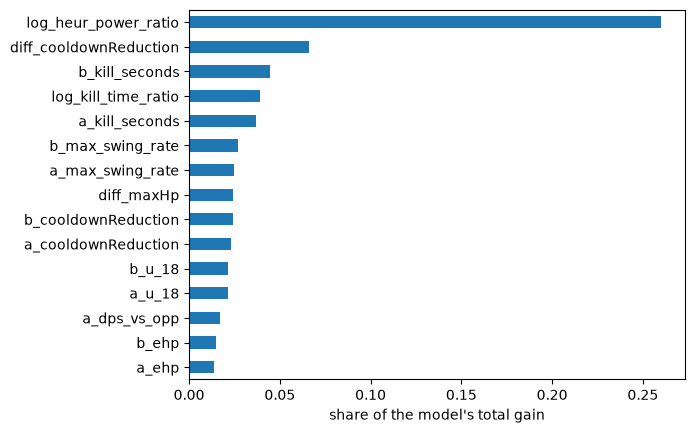

In [14]:
importance = pd.Series(model.feature_importance("gain"), index=names).sort_values(ascending=False)
(importance / importance.sum()).head(15).plot.barh()
plt.gca().invert_yaxis(); plt.xlabel("share of the model's total gain"); plt.show()

In [15]:
checked = test.assign(p=predict(model, test))
checked["round_group"] = pd.cut(checked["round"], [0, 3, 6, 9, 20])
for column in ["kind", "round_group"]:
    print(checked.groupby(column, observed=True).apply(
        lambda g: pd.Series({"fights": len(g), "log_loss": score("", g.label, g.p)["log_loss"]}),
        include_groups=False).round(3), "\n")

      fights  log_loss
kind                  
bot    324.0     0.213
run    121.0     0.231 

             fights  log_loss
round_group                  
(0, 3]        163.0     0.115
(3, 6]        159.0     0.214
(6, 9]         80.0     0.384
(9, 20]        43.0     0.315 



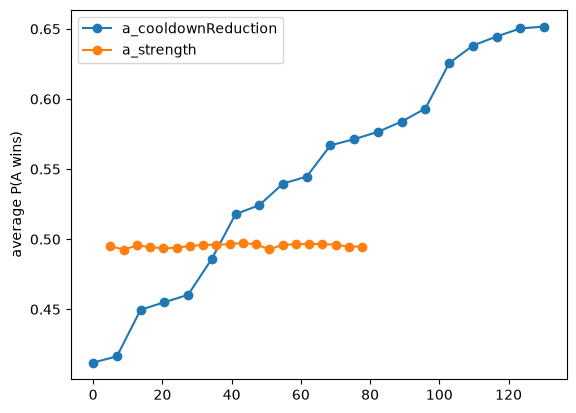

In [16]:
def partial_dependence(model, df, feature, points=20):
    grid = np.linspace(df[feature].quantile(0.05), df[feature].quantile(0.95), points)
    curve = []
    for value in grid:
        changed = df.copy()
        changed[feature] = value
        stat = feature[2:]                       # "a_strength" -> "strength"
        if f"diff_{stat}" in changed:            # keep the matching difference column consistent
            changed[f"diff_{stat}"] = changed[f"a_{stat}"] - changed[f"b_{stat}"]
        curve.append(predict(model, changed).mean())
    return grid, curve

sample = test.sample(200, random_state=0)
for feature in ["a_cooldownReduction", "a_strength"]:
    grid, curve = partial_dependence(model, sample, feature)
    plt.plot(grid, curve, marker="o", label=feature)
plt.ylabel("average P(A wins)"); plt.legend(); plt.show()

In [17]:
model.save_model("../models/fight.txt")

In [18]:
print(model.best_iteration)

622
